# Notebook 1 — Analyses commerciales
## Projet 9 — Analyse des ventes de la librairie Lapage

---

### Contexte
La librairie Lapage a ouvert son site e-commerce il y a 2 ans.
Sylvain, responsable commercial, souhaite faire le point sur l'activité
pour orienter les décisions stratégiques de l'entreprise.

### Objectif
Analyser les indicateurs commerciaux sur 24 mois (mars 2021 → février 2023) :
- Évolution du chiffre d'affaires
- Performance des produits
- Profils et comportement des clients

### Données sources
- `customers.csv` — 8 621 clients (sexe, année de naissance)
- `products.csv` — 3 286 produits (prix, catégorie)
- `Transactions.csv` — historique des achats sur 24 mois

### Livrable
Export de `df_final.csv` dans `data/processed/` pour le notebook 2.

## 1. Imports des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Paramètres d'affichage
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Chargement des données

Les données sont réparties en 3 fichiers CSV fournis par Lapage.
Le séparateur utilisé est le point-virgule `;`.

In [4]:
import os

DATA_PATH = os.path.join(os.getcwd(), "data", "raw")

transactions = pd.read_csv(os.path.join(DATA_PATH, "Transactions.csv"), sep=";", low_memory=False)
customers    = pd.read_csv(os.path.join(DATA_PATH, "customers.csv"), sep=";")
products     = pd.read_csv(os.path.join(DATA_PATH, "products.csv"), sep=";")

print("transactions :", transactions.shape)
print("customers    :", customers.shape)
print("products     :", products.shape)

transactions : (1048575, 4)
customers    : (8621, 3)
products     : (3286, 3)


## 3. Exploration des données

Avant tout nettoyage, on explore chaque table pour comprendre
sa structure, détecter les valeurs manquantes et les anomalies.

### 3.1 Table `transactions`

In [5]:
print("=== SHAPE ===")
print(transactions.shape)

print("\n=== TYPES ===")
print(transactions.dtypes)

print("\n=== APERÇU ===")
display(transactions.head())

print("\n=== NaN PAR COLONNE ===")
print(transactions.isna().sum())

print("\n=== DOUBLONS ===")
print(transactions.duplicated().sum())

print("\n=== STATISTIQUES ===")
display(transactions.describe(include='all'))

=== SHAPE ===
(1048575, 4)

=== TYPES ===
id_prod       object
date          object
session_id    object
client_id     object
dtype: object

=== APERÇU ===


,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033



=== NaN PAR COLONNE ===
id_prod       361041
date          361041
session_id    361041
client_id     361041
dtype: int64

=== DOUBLONS ===
361040

=== STATISTIQUES ===


,id_prod,date,session_id,client_id
count,687534,687534,687534,687534
unique,3265,687419,345505,8600
top,1_369,2021-10-13 17:05:59.572162,s_118668,c_1609
freq,2340,2,14,25586


### 3.2 Table `customers`

In [6]:
print("=== SHAPE ===")
print(customers.shape)

print("\n=== TYPES ===")
print(customers.dtypes)

print("\n=== APERÇU ===")
display(customers.head())

print("\n=== NaN PAR COLONNE ===")
print(customers.isna().sum())

print("\n=== DOUBLONS ===")
print(customers.duplicated().sum())

print("\n=== STATISTIQUES ===")
display(customers.describe(include='all'))

=== SHAPE ===
(8621, 3)

=== TYPES ===
client_id    object
sex          object
birth         int64
dtype: object

=== APERÇU ===


,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943



=== NaN PAR COLONNE ===
client_id    0
sex          0
birth        0
dtype: int64

=== DOUBLONS ===
0

=== STATISTIQUES ===


,client_id,sex,birth
count,8621,8621,8621.000000
unique,8621,2,NaN
top,c_4410,f,NaN
freq,1,4490,NaN
mean,NaN,NaN,1978.275606
std,NaN,NaN,16.917958
min,NaN,NaN,1929.000000
25%,NaN,NaN,1966.000000
50%,NaN,NaN,1979.000000
75%,NaN,NaN,1992.000000


### 3.3 Table `products`

In [7]:
print("=== SHAPE ===")
print(products.shape)

print("\n=== TYPES ===")
print(products.dtypes)

print("\n=== APERÇU ===")
display(products.head())

print("\n=== NaN PAR COLONNE ===")
print(products.isna().sum())

print("\n=== DOUBLONS ===")
print(products.duplicated().sum())

print("\n=== STATISTIQUES ===")
display(products.describe(include='all'))

=== SHAPE ===
(3286, 3)

=== TYPES ===
id_prod     object
price      float64
categ        int64
dtype: object

=== APERÇU ===


,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0



=== NaN PAR COLONNE ===
id_prod    0
price      0
categ      0
dtype: int64

=== DOUBLONS ===
0

=== STATISTIQUES ===


,id_prod,price,categ
count,3286,3286.000000,3286.000000
unique,3286,NaN,NaN
top,0_1421,NaN,NaN
freq,1,NaN,NaN
mean,NaN,21.863597,0.370359
std,NaN,29.849786,0.615446
min,NaN,0.620000,0.000000
25%,NaN,6.990000,0.000000
50%,NaN,13.075000,0.000000
75%,NaN,22.990000,1.000000


### Bilan de l'exploration

| Table | Lignes | NaN | Doublons | Actions nécessaires |
|---|---|---|---|---|
| `transactions` | 1 048 575 | 361 041 | 361 040 | Supprimer lignes vides + convertir date |
| `customers` | 8 621 | 0 | 0 | Aucune |
| `products` | 3 286 | 0 | 0 | Aucune |

## 4. Nettoyage des données

### 4.1 Suppression des lignes vides dans `transactions`

361 041 lignes où toutes les colonnes sont NaN simultanément.
Ce sont des artefacts d'export CSV sans valeur exploitable → on les supprime.

In [8]:
transactions.dropna(how='all', inplace=True)

print("Lignes après suppression :", transactions.shape[0])
print("NaN restants :\n", transactions.isna().sum())

Lignes après suppression : 687534
NaN restants :
 id_prod       0
date          0
session_id    0
client_id     0
dtype: int64


### 4.2 Conversion de la colonne `date`

La colonne `date` est en type `object` (texte brut).
On la convertit en `datetime` pour pouvoir faire des calculs temporels.
`errors='coerce'` transforme les valeurs invalides en NaN plutôt que de faire planter le code.

In [9]:
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')

print("Type après conversion :", transactions['date'].dtype)
print("NaN après conversion :", transactions['date'].isna().sum())
print("Période couverte :", transactions['date'].min(), "→", transactions['date'].max())

Type après conversion : datetime64[ns]
NaN après conversion : 0
Période couverte : 2021-03-01 00:01:07.843138 → 2023-02-28 23:58:30.792755


### 4.3 Vérification post-nettoyage

On identifie les produits jamais vendus et les clients sans transaction
pour avoir une vision complète de la base avant la jointure.

In [10]:
# Produits jamais vendus
produits_vendus = transactions['id_prod'].unique()
produits_jamais_vendus = products[~products['id_prod'].isin(produits_vendus)]
print(f"Produits jamais vendus : {len(produits_jamais_vendus)} sur {len(products)}")

# Clients sans transaction
clients_avec_achat = transactions['client_id'].unique()
clients_sans_achat = customers[~customers['client_id'].isin(clients_avec_achat)]
print(f"Clients sans transaction : {len(clients_sans_achat)} sur {len(customers)}")

Produits jamais vendus : 21 sur 3286
Clients sans transaction : 21 sur 8621


### 4.4 Vérification cohérence id_prod et catégorie

On vérifie que le préfixe de `id_prod` correspond bien à la catégorie
du produit — information redondante mais utile pour la rigueur.

In [27]:
products['prefix'] = products['id_prod'].str.split('_').str[0].astype(int)
print("Préfixe == categ ?", (products['prefix'] == products['categ']).all())
products.drop(columns='prefix', inplace=True)

Préfixe == categ ? True


### Bilan du nettoyage

| Action | Détail |
|---|---|
| Lignes vides supprimées | 361 041 → 687 534 lignes valides |
| Conversion date | `object` → `datetime64` |
| Produits jamais vendus | 21 sur 3 286 — conservés dans le catalogue |
| Clients sans transaction | 21 sur 8 621 — conservés dans la base |

> Ces 21 produits et 21 clients sans correspondance seront naturellement
> exclus lors de la jointure si on choisit un INNER JOIN.
> On expliquera ce choix dans la section suivante.

## 5. Jointure des tables

Les 3 tables sont liées par des clés communes :
- `transactions` ↔ `products` via `id_prod`
- `transactions` ↔ `customers` via `client_id`

On effectue deux LEFT JOIN successifs pour enrichir chaque transaction
avec le prix, la catégorie du produit et le profil du client.

**Pourquoi un LEFT JOIN ?**
On part des transactions comme table de référence.
Un LEFT JOIN conserve toutes les transactions même sans correspondance.
Le résultat confirmera si toutes les clés correspondent bien.

In [11]:
# Jointure transactions + products
df = transactions.merge(products, on='id_prod', how='left')

# Jointure avec customers
df = df.merge(customers, on='client_id', how='left')

print("Shape après jointure :", df.shape)
print("\nColonnes :", df.columns.tolist())
print("\nNaN après jointure :\n", df.isna().sum())

Shape après jointure : (687534, 8)

Colonnes : ['id_prod', 'date', 'session_id', 'client_id', 'price', 'categ', 'sex', 'birth']

NaN après jointure :
 id_prod       0
date          0
session_id    0
client_id     0
price         0
categ         0
sex           0
birth         0
dtype: int64


### Bilan de la jointure

| Colonne | Provenance |
|---|---|
| `id_prod` | transactions |
| `date` | transactions |
| `session_id` | transactions |
| `client_id` | transactions |
| `price` | products |
| `categ` | products |
| `sex` | customers |
| `birth` | customers |

0 NaN après jointure — toutes les clés correspondent parfaitement.
DataFrame final : 687 534 lignes × 8 colonnes.

## 6. Feature engineering

On crée de nouvelles variables à partir des variables existantes
pour faciliter les analyses.

| Variable | Calcul | Utilité |
|---|---|---|
| `age` | `date.dt.year - birth` | Âge du client à la date de la transaction |
| `moi

In [12]:
# Âge à la date de la transaction
df['age'] = df['date'].dt.year - df['birth']

# Mois et année
df['mois'] = df['date'].dt.to_period('M')
df['annee'] = df['date'].dt.year

# Labels catégories
df['categ_label'] = df['categ'].map({0: 'Catégorie 0', 1: 'Catégorie 1', 2: 'Catégorie 2'})

print("Nouvelles colonnes :", df.columns.tolist())
display(df.head())

Nouvelles colonnes : ['id_prod', 'date', 'session_id', 'client_id', 'price', 'categ', 'sex', 'birth', 'age', 'mois', 'annee', 'categ_label']


,id_prod,date,session_id,client_id,price,categ,sex,birth,age,mois,annee,categ_label
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,54,2021-03,2021,Catégorie 0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,61,2021-03,2021,Catégorie 0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,33,2021-03,2021,Catégorie 0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,32,2021-03,2021,Catégorie 0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,65,2021-03,2021,Catégorie 0


## 7. Analyses commerciales

### 7.1 Évolution du chiffre d'affaires mensuel

On calcule le CA mensuel en additionnant les prix de toutes les transactions
de chaque mois.

La **moyenne mobile sur 3 mois** lisse les fluctuations ponctuelles
pour révéler la tendance de fond.

> ⚠️ Février 2023 est un mois incomplet — la chute observée en fin de
> période n'est pas significative.

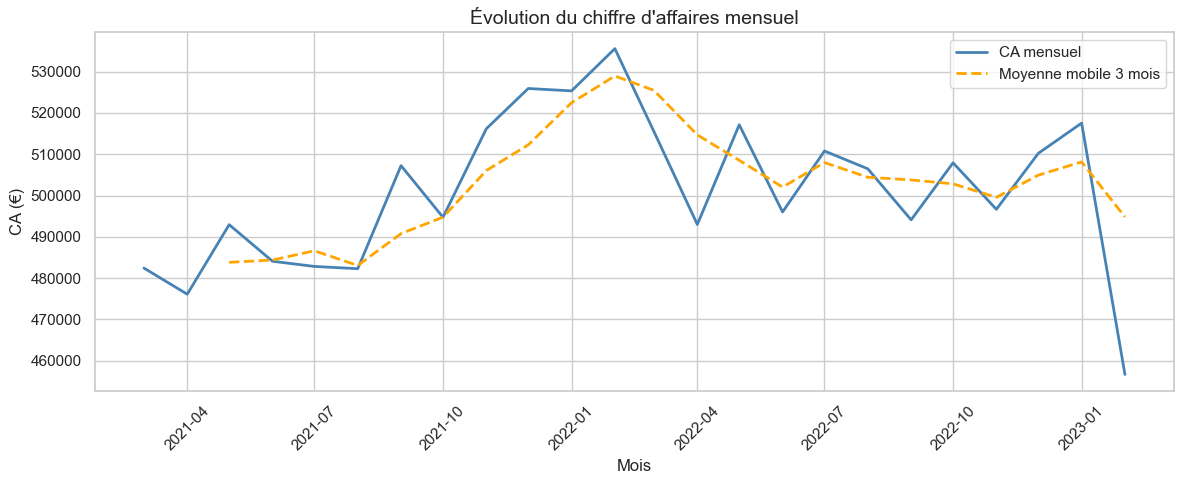

In [13]:
# CA mensuel
ca_mensuel = df.groupby('mois')['price'].sum().reset_index()
ca_mensuel.columns = ['mois', 'ca']
ca_mensuel['mois_dt'] = ca_mensuel['mois'].dt.to_timestamp()

# Moyenne mobile 3 mois
ca_mensuel['mm3'] = ca_mensuel['ca'].rolling(window=3).mean()

# Graphique
fig, ax = plt.subplots()
ax.plot(ca_mensuel['mois_dt'], ca_mensuel['ca'], color='steelblue', linewidth=2, label='CA mensuel')
ax.plot(ca_mensuel['mois_dt'], ca_mensuel['mm3'], color='orange', linewidth=2, linestyle='--', label='Moyenne mobile 3 mois')
ax.set_title("Évolution du chiffre d'affaires mensuel", fontsize=14)
ax.set_xlabel("Mois")
ax.set_ylabel("CA (€)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Ce qu'on observe :**
- CA stable entre 480 000 € et 535 000 € / mois sur 24 mois
- Pic en janvier/février 2022 — saisonnalité liée aux fêtes de fin d'année
- La moyenne mobile confirme une légère progression du CA sur 2021
- Chute en février 2023 — mois incomplet, données tronquées au 28/02
- Pas de déclin structurel observé sur la période

### 7.2 Décomposition de la série temporelle

On décompose le CA mensuel en 3 composantes pour mieux comprendre
la structure temporelle de l'activité :

- **Tendance** — évolution de fond sur la période
- **Saisonnalité** — patterns qui se répètent chaque année
- **Résidu** — ce qui n'est expliqué ni par la tendance ni par la saisonnalité

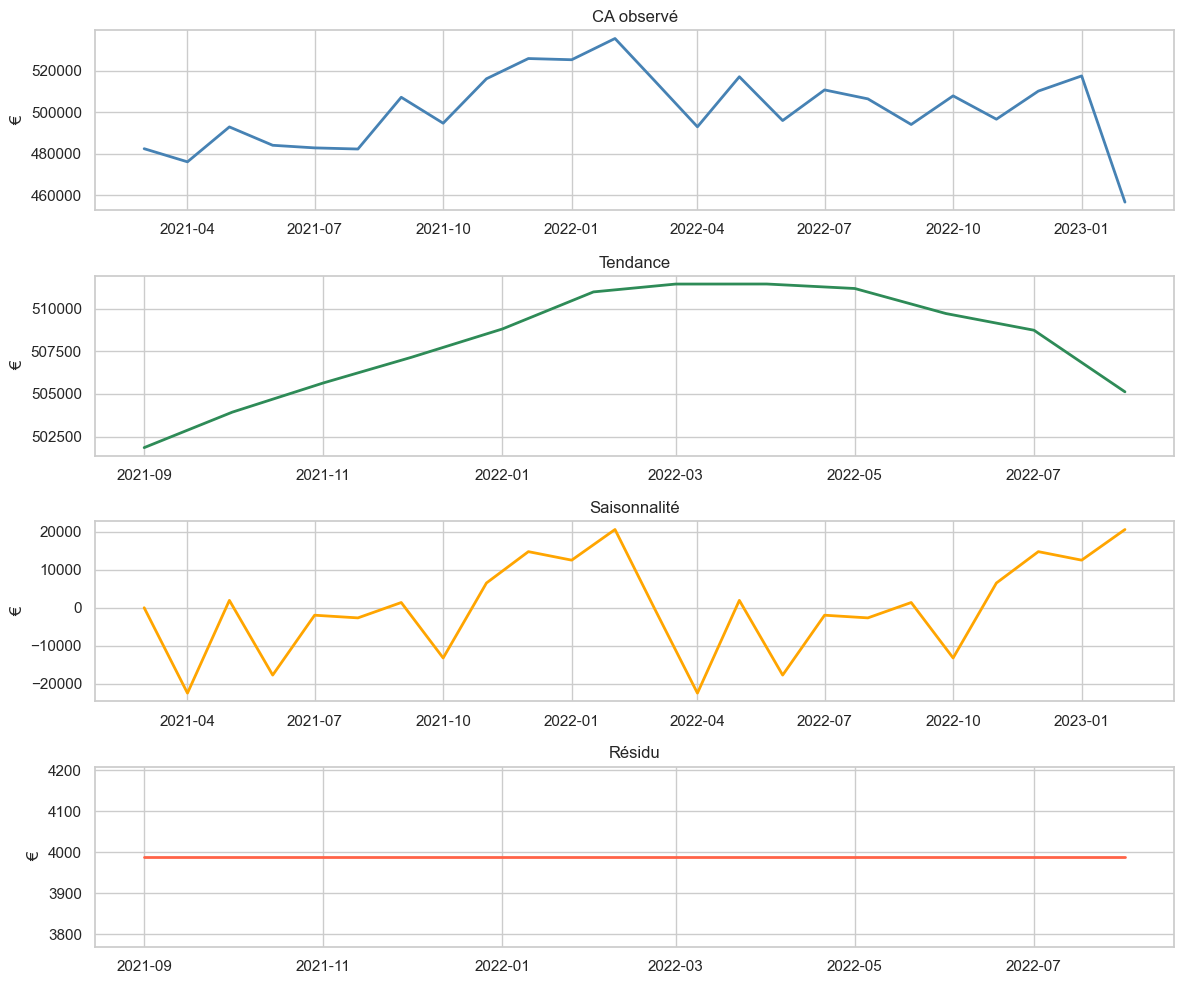

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Série temporelle indexée par date
ca_ts = ca_mensuel.set_index('mois_dt')['ca']

# Décomposition additive
decomposition = seasonal_decompose(ca_ts, model='additive', period=12)

# Graphique
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(decomposition.observed, color='steelblue', linewidth=2)
axes[0].set_title('CA observé', fontsize=12)
axes[0].set_ylabel('€')

axes[1].plot(decomposition.trend, color='seagreen', linewidth=2)
axes[1].set_title('Tendance', fontsize=12)
axes[1].set_ylabel('€')

axes[2].plot(decomposition.seasonal, color='orange', linewidth=2)
axes[2].set_title('Saisonnalité', fontsize=12)
axes[2].set_ylabel('€')

axes[3].plot(decomposition.resid, color='tomato', linewidth=2)
axes[3].set_title('Résidu', fontsize=12)
axes[3].set_ylabel('€')

plt.tight_layout()
plt.show()

**Ce qu'on observe :**
- **Tendance** — progression du CA de 502 000 € à 512 000 € sur 2021,
  plateau en 2022, légère baisse en fin de période
- **Saisonnalité** — pic en janvier/février, creux en avril et juillet —
  pattern cohérent avec les fêtes et les vacances d'été
- **Résidu** — quasi plat, signe que la tendance et la saisonnalité
  expliquent bien l'essentiel des variations

> ⚠️ Avec seulement 24 mois de données, la décomposition sur une période
> de 12 mois est limitée — les résultats sont à interpréter avec prudence.

### 7.3 Chiffre d'affaires par catégorie

On analyse la répartition du CA entre les 3 catégories de produits
identifiées dans le catalogue (`categ` : 0, 1, 2).
Les catégories ne sont pas labelisées dans les données fournies —
leur nature exacte mériterait d'être clarifiée avec l'équipe métier.

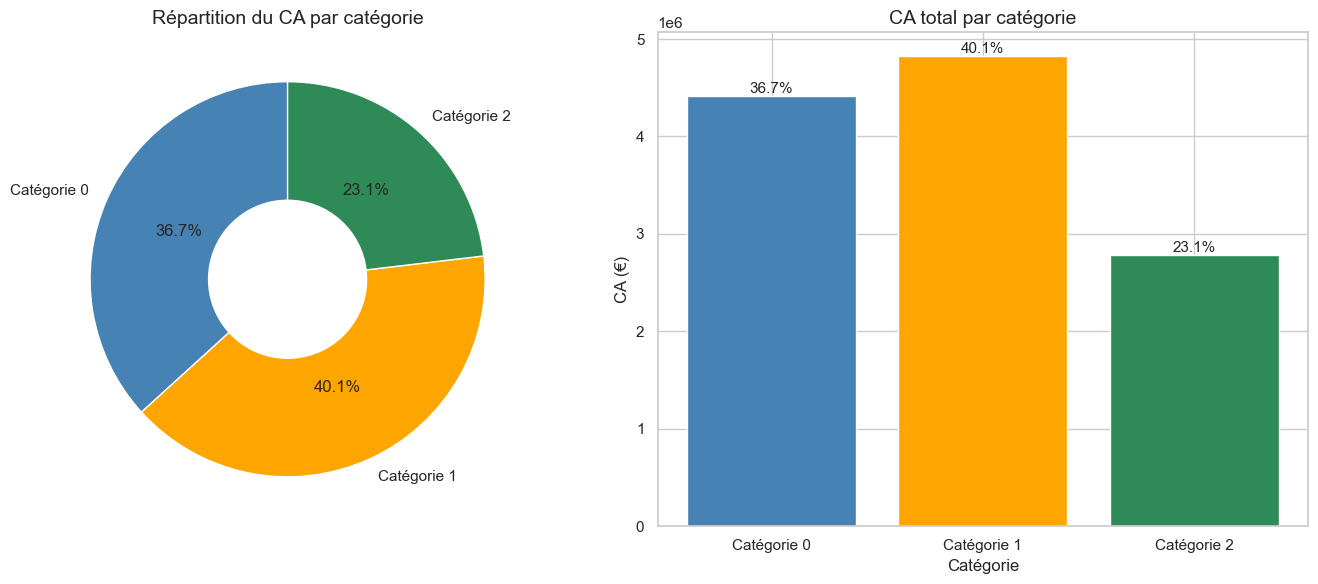

         categ          ca   pct
0  Catégorie 0  4419730.97  36.7
1  Catégorie 1  4827657.11  40.1
2  Catégorie 2  2780275.02  23.1


In [15]:
# CA total par catégorie
ca_categ = df.groupby('categ_label')['price'].sum().reset_index()
ca_categ.columns = ['categ', 'ca']
ca_categ['pct'] = (ca_categ['ca'] / ca_categ['ca'].sum() * 100).round(1)

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Donut
axes[0].pie(ca_categ['ca'], labels=ca_categ['categ'],
            autopct='%1.1f%%', colors=['steelblue', 'orange', 'seagreen'],
            startangle=90, wedgeprops=dict(width=0.6))
axes[0].set_title("Répartition du CA par catégorie", fontsize=14)

# Barres
bars = axes[1].bar(ca_categ['categ'], ca_categ['ca'],
                   color=['steelblue', 'orange', 'seagreen'])
axes[1].set_title("CA total par catégorie", fontsize=14)
axes[1].set_xlabel("Catégorie")
axes[1].set_ylabel("CA (€)")
for bar, pct in zip(bars, ca_categ['pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{pct}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print(ca_categ)

**Ce qu'on observe :**
- **Catégorie 1** domine avec 40.1% du CA
- **Catégorie 0** représente 36.7% du CA
- **Catégorie 2** ne représente que 23.1% du CA malgré des prix plus élevés

> Ces chiffres sont à croiser avec le volume de ventes par catégorie
> pour comprendre le rapport volume/valeur — fait dans la section 7.7.

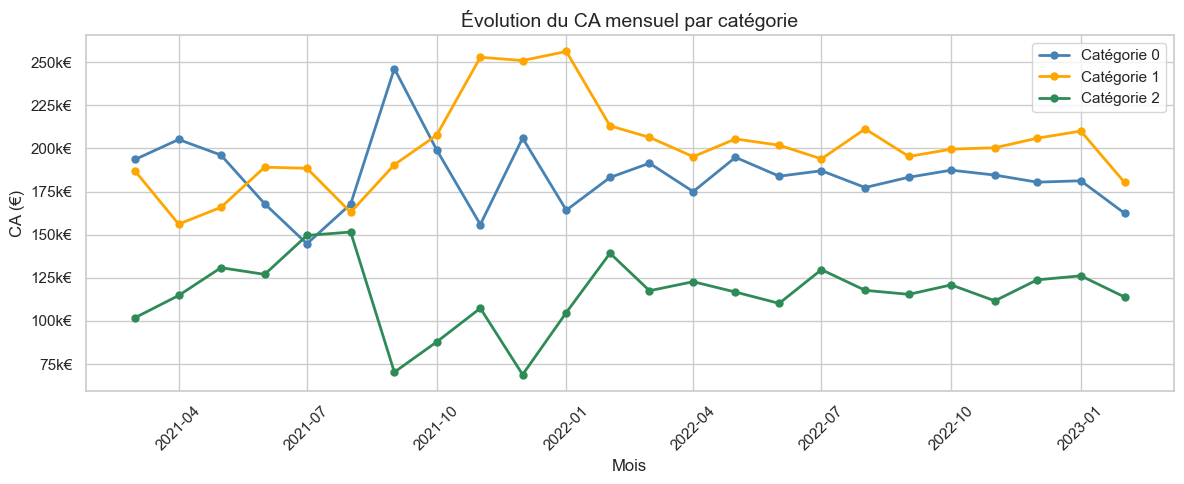

In [16]:
import matplotlib.ticker as mticker

# CA mensuel par catégorie
ca_mensuel_categ = df.groupby(['mois', 'categ_label'])['price'].sum().reset_index()
ca_mensuel_categ['mois_dt'] = ca_mensuel_categ['mois'].dt.to_timestamp()

colors = {'Catégorie 0': 'steelblue', 'Catégorie 1': 'orange', 'Catégorie 2': 'seagreen'}

fig, ax = plt.subplots()
for categ, group in ca_mensuel_categ.groupby('categ_label'):
    ax.plot(group['mois_dt'], group['price'],
            marker='o', markersize=5, linewidth=2,
            label=categ, color=colors[categ])

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k€'))
ax.set_title("Évolution du CA mensuel par catégorie", fontsize=14)
ax.set_xlabel("Mois")
ax.set_ylabel("CA (€)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Ce qu'on observe :**
- **Catégorie 1** progresse et dépasse la catégorie 0 à partir de fin 2021
- **Catégorie 0** reste stable autour de 180k€ / mois
- **Catégorie 2** est la plus volatile — grands écarts d'un mois à l'autre
- Pic notable en **août 2021** pour la catégorie 0 — à investiguer
- Toutes les catégories chutent en février 2023 — mois incomplet

### 7.3 bis — CA annuel par catégorie

Vue complémentaire — on compare l'évolution du CA par catégorie
année par année pour détecter des tendances structurelles.

> ⚠️ 2023 ne contient que 2 mois de données — les valeurs sont non comparables.

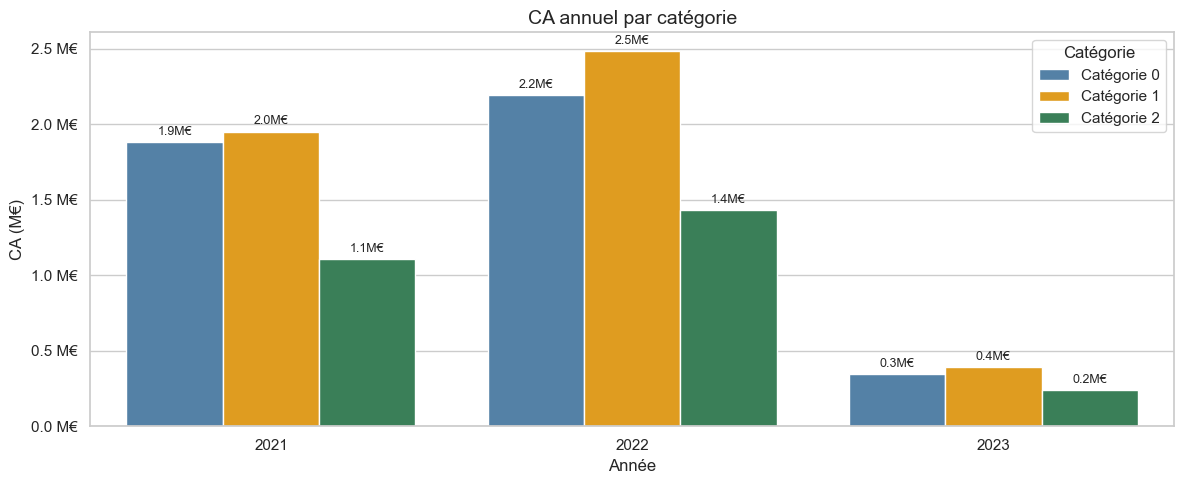

In [28]:
ca_annuel_categ = df.groupby(['annee', 'categ_label'])['price'].sum().reset_index()
ca_annuel_categ.columns = ['annee', 'categ_label', 'ca']

fig, ax = plt.subplots()
sns.barplot(data=ca_annuel_categ, x='annee', y='ca', hue='categ_label',
            palette=['steelblue', 'orange', 'seagreen'], ax=ax)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f} M€'))
ax.set_title("CA annuel par catégorie", fontsize=14)
ax.set_xlabel("Année")
ax.set_ylabel("CA (M€)")
ax.legend(title='Catégorie')

for container in ax.containers:
    ax.bar_label(container,
                 labels=[f'{v.get_height()/1e6:.1f}M€' for v in container],
                 padding=3, fontsize=9)

plt.tight_layout()
plt.show()

**Ce qu'on observe :**
- 2021 → 2022 : progression sur les 3 catégories
- Catégorie 1 passe de 2.0M€ à 2.5M€ → croissance la plus forte
- Catégorie 2 passe de 1.1M€ à 1.4M€ → progression notable
- 2023 : chute apparente → normal, seulement 2 mois de données

### 7.4 Nombre de clients actifs par mois

On compte le nombre de clients distincts ayant effectué
au moins un achat chaque mois.

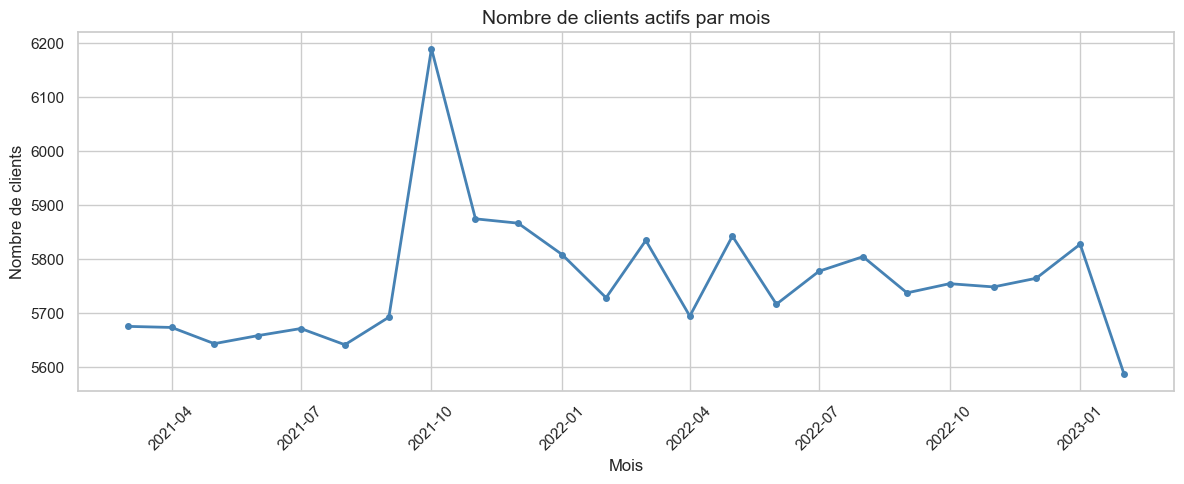

       mois  nb_clients
0   2021-03        5676
1   2021-04        5674
2   2021-05        5644
3   2021-06        5659
4   2021-07        5672
5   2021-08        5642
6   2021-09        5693
7   2021-10        6190
8   2021-11        5875
9   2021-12        5867
10  2022-01        5809
11  2022-02        5729
12  2022-03        5835
13  2022-04        5695
14  2022-05        5843
15  2022-06        5717
16  2022-07        5778
17  2022-08        5805
18  2022-09        5738
19  2022-10        5755
20  2022-11        5749
21  2022-12        5765
22  2023-01        5828
23  2023-02        5587


In [17]:
clients_mois = df.groupby('mois')['client_id'].nunique().reset_index()
clients_mois.columns = ['mois', 'nb_clients']
clients_mois['mois_dt'] = clients_mois['mois'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.plot(clients_mois['mois_dt'], clients_mois['nb_clients'],
        color='steelblue', linewidth=2, marker='o', markersize=4)
ax.set_title("Nombre de clients actifs par mois", fontsize=14)
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de clients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(clients_mois[['mois', 'nb_clients']].to_string())

**Ce qu'on observe :**
- Base clients stable entre 5 600 et 5 900 clients actifs / mois
- Pic notable en **octobre 2021 à 6 190 clients** — probable campagne 
  marketing ou promotion
- Chute en février 2023 — mois incomplet
- La stabilité de la base active sur 2 ans est un signal positif 
  — Lapage fidélise bien ses clients

### 7.5 Nombre de transactions par mois

On suit le volume mensuel de transactions pour détecter
d'éventuelles tendances ou saisonnalités.

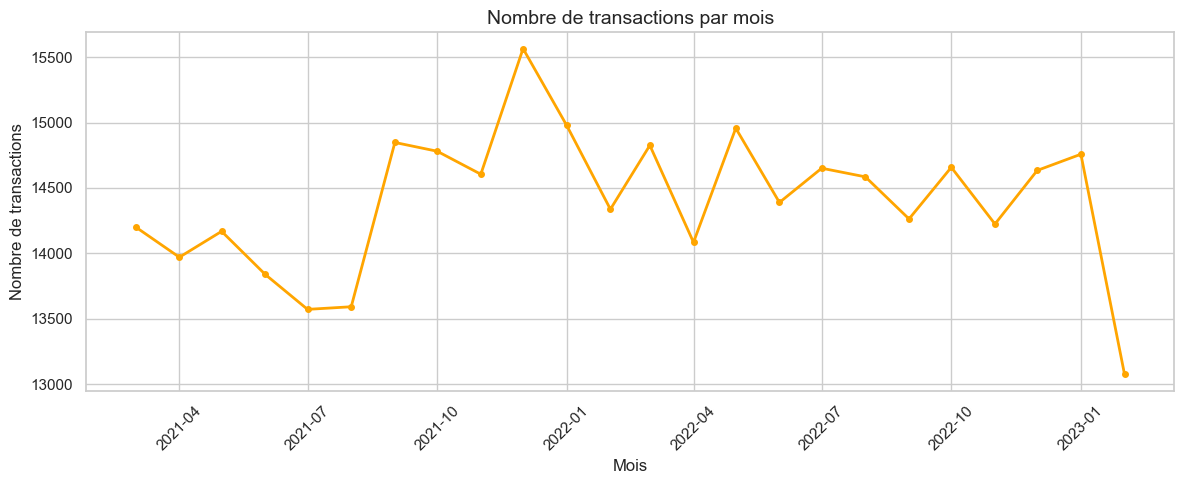

In [18]:
transactions_mois = df.groupby('mois')['session_id'].nunique().reset_index()
transactions_mois.columns = ['mois', 'nb_transactions']
transactions_mois['mois_dt'] = transactions_mois['mois'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.plot(transactions_mois['mois_dt'], transactions_mois['nb_transactions'],
        color='orange', linewidth=2, marker='o', markersize=4)
ax.set_title("Nombre de transactions par mois", fontsize=14)
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Ce qu'on observe :**
- Volume stable entre 13 500 et 15 500 transactions / mois
- Creux en juillet 2021 — saisonnalité estivale
- Pic en décembre 2021 — achats de fêtes
- Chute en février 2023 — mois incomplet

### 7.6 Nombre de produits vendus par mois

On compte le nombre de produits distincts vendus chaque mois
pour mesurer la diversité de l'offre achetée.

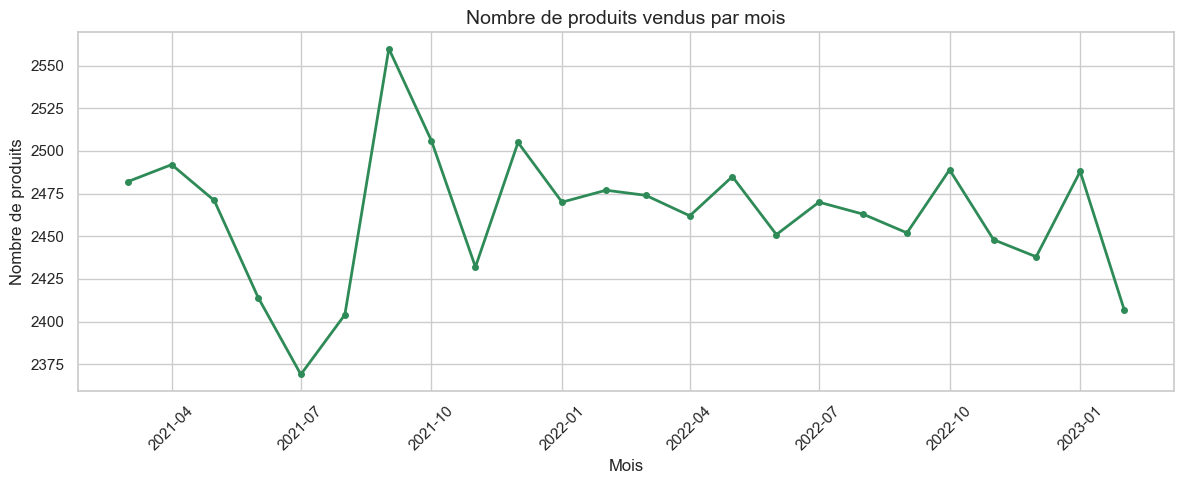

In [19]:
produits_mois = df.groupby('mois')['id_prod'].nunique().reset_index()
produits_mois.columns = ['mois', 'nb_produits']
produits_mois['mois_dt'] = produits_mois['mois'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.plot(produits_mois['mois_dt'], produits_mois['nb_produits'],
        color='seagreen', linewidth=2, marker='o', markersize=4)
ax.set_title("Nombre de produits vendus par mois", fontsize=14)
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de produits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Ce qu'on observe :**
- Entre 2 375 et 2 560 produits distincts vendus par mois
- Creux en juillet 2021 — cohérent avec la baisse des transactions
- Pic en septembre 2021 — rentrée scolaire ?
- Diversité de l'offre stable — Lapage vend régulièrement l'ensemble de son catalogue
- Chute en février 2023 — mois incomplet

### 7.7 Top 10 et Flop 10 des références produits

On identifie les produits les plus et les moins performants en CA
pour aider Lapage à orienter ses décisions d'approvisionnement.

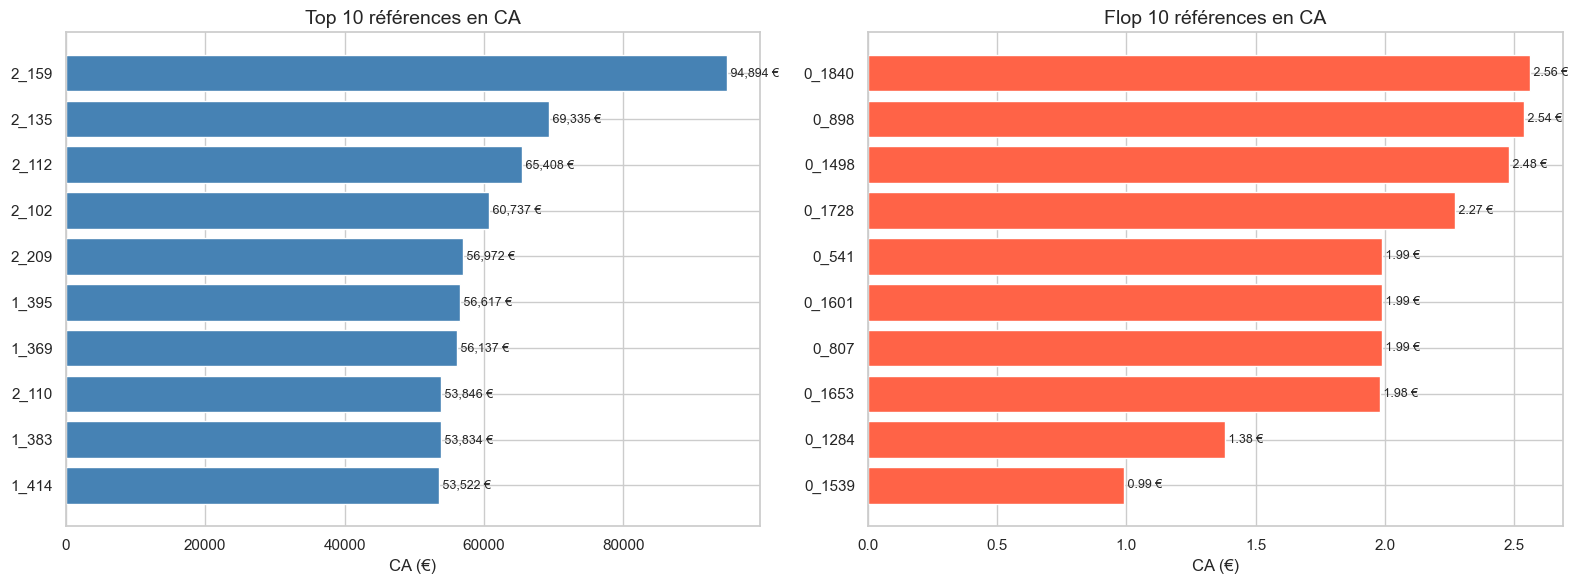

In [20]:
# CA par produit
ca_produit = df.groupby('id_prod')['price'].sum().reset_index()
ca_produit.columns = ['id_prod', 'ca']
ca_produit = ca_produit.sort_values('ca', ascending=False)

# Top 10 et Flop 10
top10 = ca_produit.head(10)
flop10 = ca_produit.tail(10)

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10['id_prod'], top10['ca'], color='steelblue')
axes[0].set_title("Top 10 références en CA", fontsize=14)
axes[0].set_xlabel("CA (€)")
axes[0].invert_yaxis()
for i, (val) in enumerate(top10['ca']):
    axes[0].text(val, i, f' {val:,.0f} €', va='center', fontsize=9)

axes[1].barh(flop10['id_prod'], flop10['ca'], color='tomato')
axes[1].set_title("Flop 10 références en CA", fontsize=14)
axes[1].set_xlabel("CA (€)")
axes[1].invert_yaxis()
for i, (val) in enumerate(flop10['ca']):
    axes[1].text(val, i, f' {val:,.2f} €', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Ce qu'on observe :**

**Top 10 :**
- Dominé par la **catégorie 2** (préfixe `2_`) — produits chers, très rentables
- Le produit `2_159` est leader avec 94 894 €
- 6 produits sur 10 sont en catégorie 2, 4 en catégorie 1 → aucun en catégorie 0

**Flop 10 :**
- Tous en **catégorie 0** (préfixe `0_`) — produits très peu chers
- CA inférieur à 2.56 € sur 24 mois → vendus une seule fois à prix très bas
- Ce sont des flops en CA mais pas forcément en volume

**Insight clé :**
La catégorie 2 génère le plus de valeur par produit.
La mettre davantage en avant pourrait booster significativement le CA global.

### 7.8 Top 3 produits en volume par année

On identifie les produits les plus vendus en quantité par année.
A croiser avec le Top 10 en CA — les meilleurs en volume
ne sont pas forcément les meilleurs en valeur.

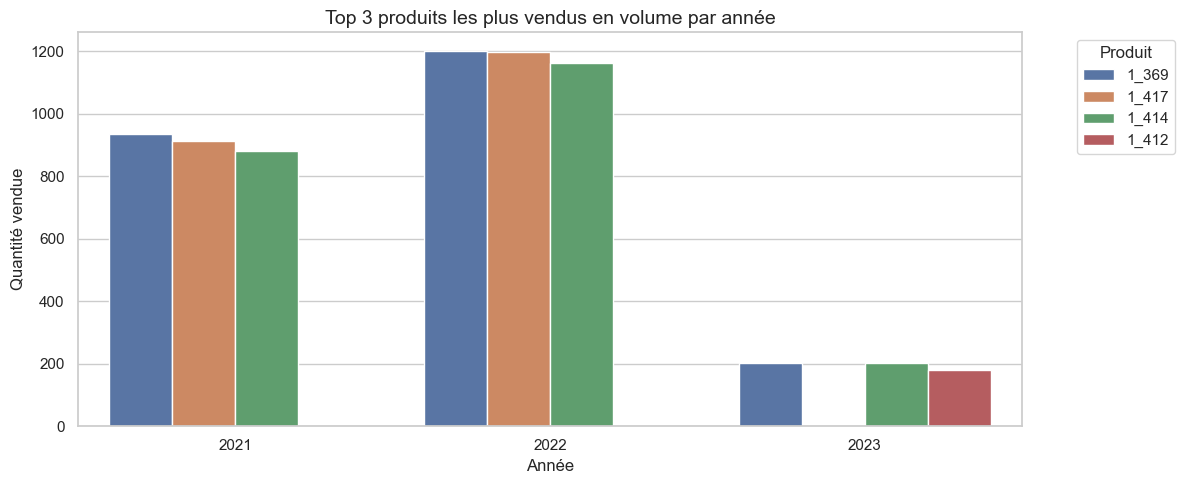

      annee id_prod  volume annee_str
2582   2021   1_369     935      2021
2635   2021   1_417     912      2021
2632   2021   1_414     881      2021
5806   2022   1_369    1201      2022
5859   2022   1_417    1197      2022
5856   2022   1_414    1162      2022
8657   2023   1_369     204      2023
8702   2023   1_414     203      2023
8700   2023   1_412     179      2023


In [21]:
# Top 3 en volume par année
top_vol = df.groupby(['annee', 'id_prod']).size().reset_index(name='volume')
top_3_vol = top_vol.sort_values(['annee', 'volume'], ascending=[True, False])
top_3_vol = top_3_vol.groupby('annee').head(3)
top_3_vol['annee_str'] = top_3_vol['annee'].astype(str)

# Graphique
fig, ax = plt.subplots()
sns.barplot(data=top_3_vol, x='annee_str', y='volume', hue='id_prod', ax=ax)
ax.set_title("Top 3 produits les plus vendus en volume par année", fontsize=14)
ax.set_xlabel("Année")
ax.set_ylabel("Quantité vendue")
ax.legend(title='Produit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(top_3_vol)

### 7.9 Répartition par catégorie — volume vs valeur

On croise le volume de ventes et le CA par catégorie pour
comprendre le rapport quantité/valeur de chaque catégorie.

   categ_label  pct_volume  pct_ca
0  Catégorie 0        60.4    36.7
1  Catégorie 1        34.3    40.1
2  Catégorie 2         5.3    23.1


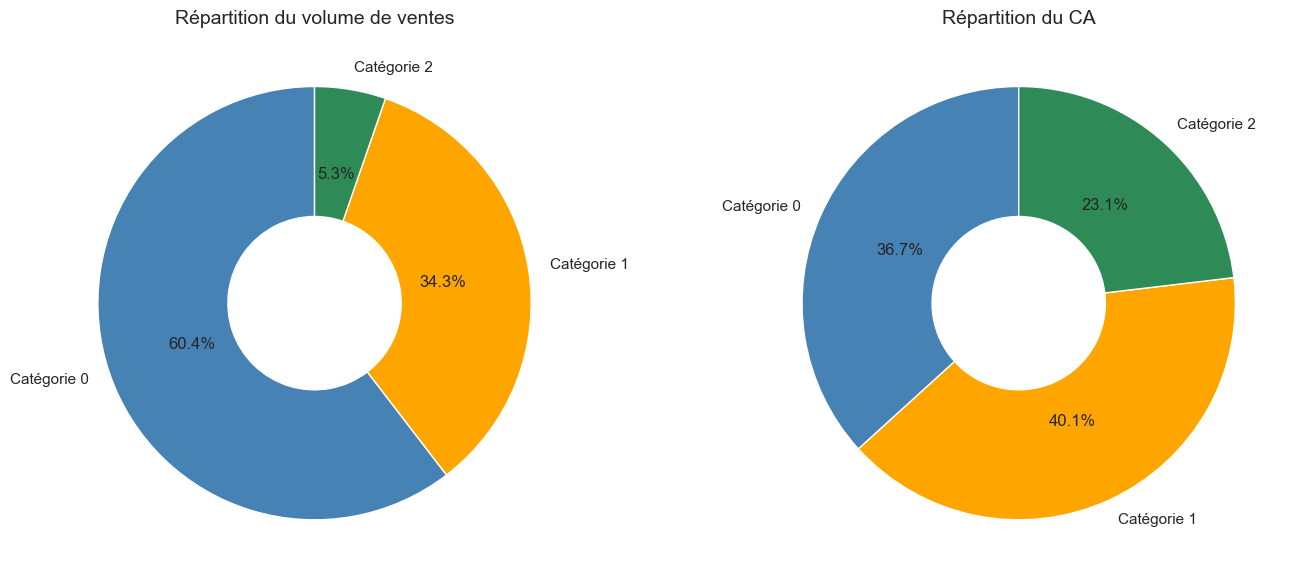

In [22]:
# Volume par catégorie
volume_categ = df.groupby('categ_label').size().reset_index(name='volume')
volume_categ['pct_volume'] = (volume_categ['volume'] / volume_categ['volume'].sum() * 100).round(1)

# CA par catégorie
ca_categ2 = df.groupby('categ_label')['price'].sum().reset_index()
ca_categ2['pct_ca'] = (ca_categ2['price'] / ca_categ2['price'].sum() * 100).round(1)

# Fusion
recap = volume_categ.merge(ca_categ2, on='categ_label')
print(recap[['categ_label', 'pct_volume', 'pct_ca']])

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(volume_categ['volume'], labels=volume_categ['categ_label'],
            autopct='%1.1f%%', colors=['steelblue', 'orange', 'seagreen'],
            startangle=90, wedgeprops=dict(width=0.6))
axes[0].set_title("Répartition du volume de ventes", fontsize=14)

axes[1].pie(ca_categ2['price'], labels=ca_categ2['categ_label'],
            autopct='%1.1f%%', colors=['steelblue', 'orange', 'seagreen'],
            startangle=90, wedgeprops=dict(width=0.6))
axes[1].set_title("Répartition du CA", fontsize=14)

plt.tight_layout()
plt.show()

**Ce qu'on observe — le paradoxe catégorie 2 :**

| Catégorie | Volume | CA |
|---|---|---|
| Catégorie 0 | 60.4% | 36.7% |
| Catégorie 1 | 34.3% | 40.1% |
| Catégorie 2 | 5.3% | 23.1% |

- **Catégorie 0** — vendue en masse mais peu chère → beaucoup de volume, peu de valeur
- **Catégorie 1** — bon équilibre volume/valeur
- **Catégorie 2** — seulement 5.3% des ventes mais 23.1% du CA

**Insight clé :**
La catégorie 2 est massivement sous-exploitée en volume.
Augmenter sa visibilité pourrait avoir un impact fort sur le CA
sans nécessiter d'augmenter le nombre de transactions.

### 7.10 Panier moyen mensuel

Le panier moyen = CA total / nombre de sessions uniques par mois.
Il mesure la valeur moyenne dépensée par visite.

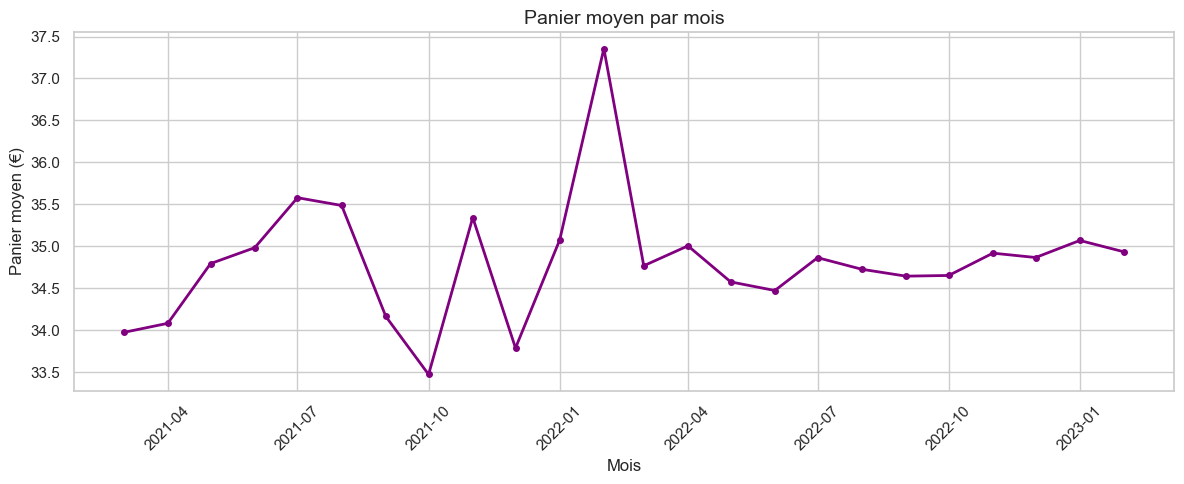

Panier moyen global : 34.81 €


In [30]:
ca_mois = df.groupby('mois')['price'].sum()
sessions_mois = df.groupby('mois')['session_id'].nunique()
panier_moyen_mois = (ca_mois / sessions_mois).reset_index()
panier_moyen_mois.columns = ['mois', 'panier_moyen']
panier_moyen_mois['mois_dt'] = panier_moyen_mois['mois'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.plot(panier_moyen_mois['mois_dt'], panier_moyen_mois['panier_moyen'],
        color='purple', linewidth=2, marker='o', markersize=4)
ax.set_title("Panier moyen par mois", fontsize=14)
ax.set_xlabel("Mois")
ax.set_ylabel("Panier moyen (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Panier moyen global : {df['price'].sum() / df['session_id'].nunique():.2f} €")

**Ce qu'on observe :**
- Panier moyen global : **34.81 €**
- Stable entre 33.5 € et 35.5 € sur la majorité de la période
- Pic notable en **février 2022 à 37.3 €** — cohérent avec le pic de CA
- Creux en **octobre 2021 à 33.5 €** — malgré le pic de clients ce mois-là
  → beaucoup de clients mais petits achats
- Signal positif : le panier moyen ne baisse pas sur 2 ans

## 8. Analyse des profils clients

### 8.1 Identification des clients BtoB

On analyse la distribution du CA par client pour identifier
les clients atypiques dont le comportement d'achat est radicalement
différent des clients BtoC.

In [23]:
# CA total par client
ca_client = df.groupby('client_id')['price'].sum().reset_index()
ca_client.columns = ['client_id', 'ca_total']
ca_client = ca_client.sort_values('ca_total', ascending=False)

print("Top 10 clients par CA :")
print(ca_client.head(10).to_string())

print("\nStatistiques CA par client :")
print(ca_client['ca_total'].describe())

Top 10 clients par CA :
     client_id   ca_total
677     c_1609  326039.89
4388    c_4958  290227.03
6337    c_6714  153918.60
2724    c_3454  114110.57
634     c_1570    5285.82
2513    c_3263    5276.87
1268    c_2140    5260.18
2108    c_2899    5214.05
7006    c_7319    5155.77
7715    c_7959    5135.75

Statistiques CA par client :
count      8600.000000
mean       1398.565477
std        5202.771679
min           6.310000
25%         562.730000
50%        1045.695000
75%        1797.720000
max      326039.890000
Name: ca_total, dtype: float64


Le gap entre le 4ème client (114 110 €) et le 5ème (5 285 €) est
très clairement visible — on fixe le seuil BtoB à **100 000 €**.

Clients BtoB : 4
     client_id   ca_total
677     c_1609  326039.89
4388    c_4958  290227.03
6337    c_6714  153918.60
2724    c_3454  114110.57

CA BtoB : 884,296 € (7.4%)
CA BtoC : 11,143,367 € (92.6%)


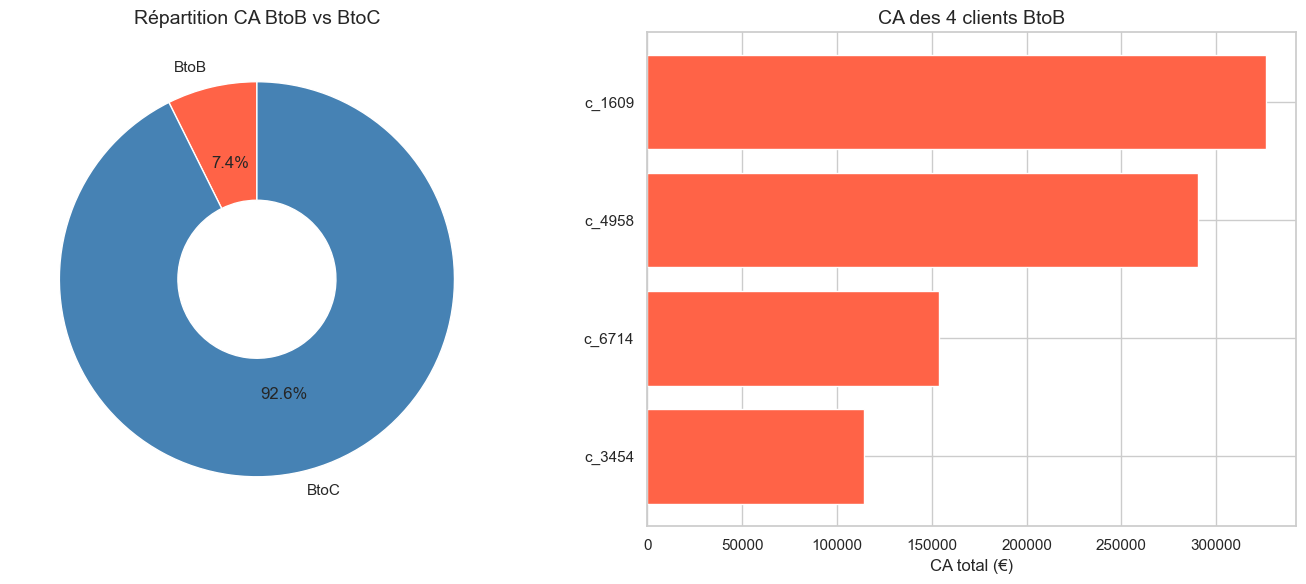

In [24]:
# Séparation BtoB / BtoC
seuil_btob = 100000
btob = ca_client[ca_client['ca_total'] > seuil_btob]
btoc = ca_client[ca_client['ca_total'] <= seuil_btob]

# CA BtoB vs BtoC
ca_btob = btob['ca_total'].sum()
ca_btoc = btoc['ca_total'].sum()
ca_total = ca_client['ca_total'].sum()

print(f"Clients BtoB : {len(btob)}")
print(btob.to_string())
print(f"\nCA BtoB : {ca_btob:,.0f} € ({ca_btob/ca_total*100:.1f}%)")
print(f"CA BtoC : {ca_btoc:,.0f} € ({ca_btoc/ca_total*100:.1f}%)")

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie([ca_btob, ca_btoc], labels=['BtoB', 'BtoC'],
            autopct='%1.1f%%', colors=['tomato', 'steelblue'],
            startangle=90, wedgeprops=dict(width=0.6))
axes[0].set_title("Répartition CA BtoB vs BtoC", fontsize=14)

axes[1].barh(btob['client_id'], btob['ca_total'], color='tomato')
axes[1].set_title("CA des 4 clients BtoB", fontsize=14)
axes[1].set_xlabel("CA total (€)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Les 4 clients BtoB identifiés :**

| Client | CA total |
|---|---|
| c_1609 | 326 040 € |
| c_4958 | 290 227 € |
| c_6714 | 153 919 € |
| c_3454 | 114 111 € |

- 4 clients = 7.4% du CA total → à sécuriser stratégiquement
- Gap énorme avec le 5ème client (5 285 €) — seuil 100 000 € justifié
- Ces clients seront exclus du notebook 2 pour ne pas fausser
  les tests statistiques sur les BtoC

### 8.2 Courbe de Lorenz et coefficient de Gini

La courbe de Lorenz mesure l'inégalité de distribution du CA entre les clients.
Plus elle s'éloigne de la diagonale, plus le CA est concentré
sur un petit nombre de clients.

Le **coefficient de Gini** synthétise cette inégalité en un seul chiffre :
- 0 = égalité parfaite (tous les clients dépensent pareil)
- 1 = inégalité totale (un seul client fait tout le CA)

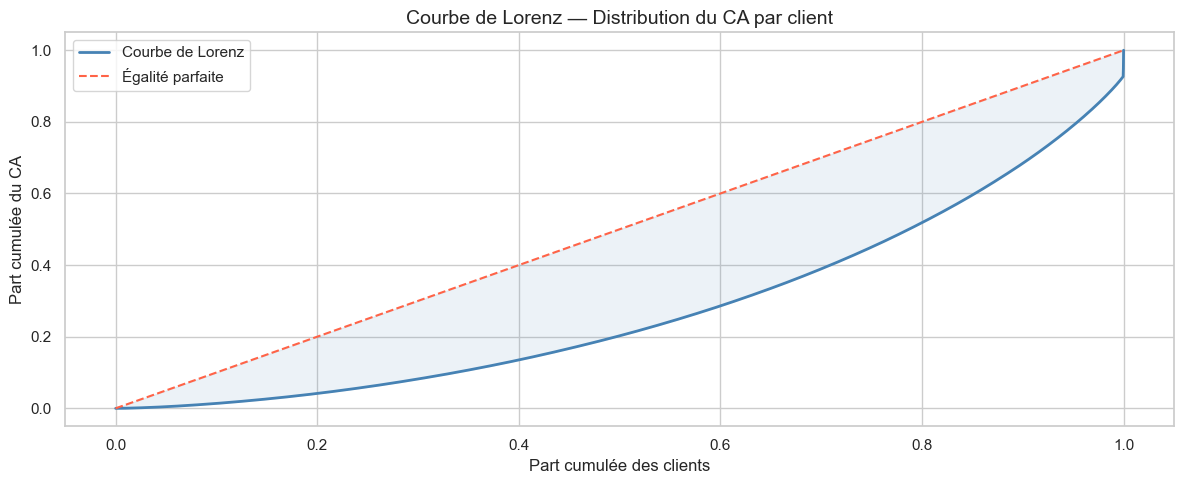

Coefficient de Gini : 0.442


In [25]:
# Tri par CA croissant
lorenz = ca_client['ca_total'].sort_values().reset_index(drop=True)

# Parts cumulées
lorenz_cum = lorenz.cumsum() / lorenz.sum()
clients_cum = (lorenz.index + 1) / len(lorenz)

# Graphique
fig, ax = plt.subplots()
ax.plot(clients_cum, lorenz_cum, color='steelblue', linewidth=2, label='Courbe de Lorenz')
ax.plot([0, 1], [0, 1], color='tomato', linestyle='--', linewidth=1.5, label='Égalité parfaite')
ax.fill_between(clients_cum, lorenz_cum, clients_cum, alpha=0.1, color='steelblue')
ax.set_title("Courbe de Lorenz — Distribution du CA par client", fontsize=14)
ax.set_xlabel("Part cumulée des clients")
ax.set_ylabel("Part cumulée du CA")
ax.legend()
plt.tight_layout()
plt.show()

# Coefficient de Gini
gini = 1 - 2 * lorenz_cum.mean()
print(f"Coefficient de Gini : {gini:.3f}")

**Ce qu'on observe :**
- Coefficient de Gini : **0.442** → inégalité modérée à forte
- Les 20% de clients les plus dépensiers génèrent environ 75% du CA
- Les 4 clients BtoB tirent ce coefficient vers le haut
- Sans eux le Gini serait probablement autour de 0.38

**Recommandation :**
Fidéliser les meilleurs clients BtoC et sécuriser les contrats BtoB
est stratégiquement prioritaire — la base de CA est concentrée
sur peu de clients.

## 9. Export des données

On exporte le dataframe final nettoyé pour le notebook 2.

In [26]:
EXPORT_PATH = os.path.join(os.getcwd(), "data", "processed", "df_final.csv")

df.to_csv(EXPORT_PATH, index=False, sep=";")

print(f"Export réussi : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Chemin : {EXPORT_PATH}")

Export réussi : 687534 lignes × 12 colonnes
Chemin : c:\Users\Candidat\Desktop\Informatique\OPEN CLASSROOM\P9 FINAL STATEMENT\data\processed\df_final.csv


## 10. Conclusion — Synthèse des insights commerciaux

### Activité générale
- CA total de **12 027 663 €** sur 24 mois
- CA mensuel moyen de **501 153 €** — activité stable et régulière
- Aucun déclin structurel observé sur la période

### Produits
- **Catégorie 2** sous-exploitée : 5.3% des ventes mais 23.1% du CA
  → levier de croissance prioritaire
- Top en CA dominé par la catégorie 2 — top en volume par la catégorie 1
- 21 produits jamais vendus sur 24 mois → à revoir dans le catalogue

### Clients
- Base stable de ~5 750 clients actifs / mois → bonne fidélisation
- 4 clients BtoB représentent **7.4% du CA** → à sécuriser
- Gini de 0.442 → CA concentré sur peu de clients

### Points d'attention
- Pic d'octobre 2021 (6 190 clients) — cause à investiguer
- Février 2023 incomplet — ne pas interpréter la chute comme un déclin
- Catégories non labelisées — à clarifier avec l'équipe métier